# Customer Churn — Segmentation
**Input:** `telco_churn_features.csv` + churn probabilities from Phase 3  
**Method:** K-Means clustering on RFM-style features  
**Goal:** Group customers into actionable segments for targeted retention

In [27]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

df = pd.read_csv("../data/processed/telco_churn_features.csv")
model = joblib.load("../models/lgbm_churn_model.pkl")
feature_names = joblib.load("../models/feature_names.pkl")

df["tenure_group"] = df["tenure_group"].map({
    "New": 0, "Developing": 1, "Mature": 2, "Loyal": 3
})

X = df[feature_names]
df["churn_probability"] = model.predict_proba(X)[:,1]

print("Shape:", df.shape)
print("Churn probability range:", df["churn_probability"].min().round(3),
      "to", df["churn_probability"].max().round(3))

Shape: (7032, 27)
Churn probability range: 0.003 to 0.966


## 1. Select Clustering Features
Using 4 RFM-style features that best capture customer behaviour and risk.

In [28]:
cluster_features = [
    "tenure",
    "MonthlyCharges",
    "num_services",
    "churn_probability"
]

X_cluster = df[cluster_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print("Clustering feature shapes:", X_scaled.shape)
X_cluster.describe().round(3)

Clustering feature shapes: (7032, 4)


,tenure,MonthlyCharges,num_services,churn_probability
count,7032.000,7032.000,7032.000,7032.000
mean,32.422,64.798,2.941,0.333
std,24.545,30.086,1.844,0.303
min,1.000,18.250,0.000,0.003
25%,9.000,35.588,1.000,0.051
50%,29.000,70.350,3.000,0.232
75%,55.000,89.862,4.000,0.598
max,72.000,118.750,7.000,0.966


## 2. Find Optimal K — Elbow + Silhouette
Elbow method finds where inertia stops dropping sharply.  
Silhouette score measures how well separated the clusters are (higher = better).

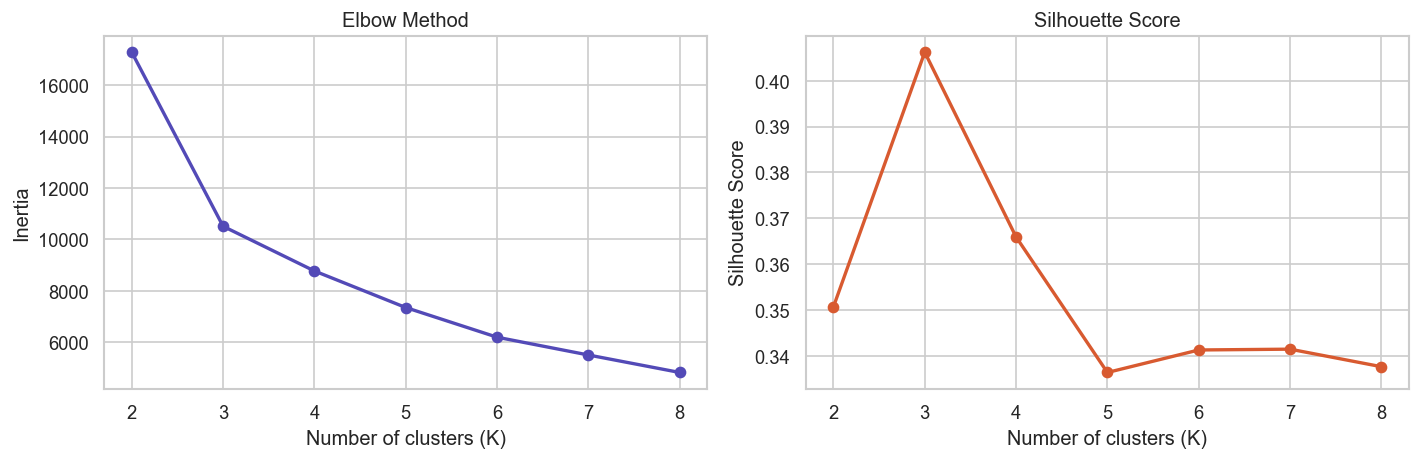

Silhouette scores:
 K=2: 0.3507
 K=3: 0.4062
 K=4: 0.3659
 K=5: 0.3364
 K=6: 0.3413
 K=7: 0.3414
 K=8: 0.3376


In [29]:
inertias = []
silhouettes = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, lbl))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_range), inertias, marker="o",
             color="#534AB7", linewidth="2")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters (K)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(K_range), silhouettes, marker="o",
             color="#D85A30", linewidth="2")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of clusters (K)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

print("Silhouette scores:")
for k, s in zip(K_range, silhouettes):
    print(f" K={k}: {s:.4f}")

> **K=3 selected** based on:
> - Silhouette score peaks at K=3 (0.406) — highest across all K values
> - Elbow curve bends sharply between K=2 and K=3


## 3. Train K-Means with Optimal K

In [30]:
BEST_K = 3

kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
df["segment"] = kmeans.fit_predict(X_scaled)

print("Segment distribution:")
print(df["segment"].value_counts().sort_index())

Segment distribution:
segment
0    2511
1    2421
2    2100
Name: count, dtype: int64


## 4. Analyse Each Segment

In [31]:
segment_stats = df.groupby("segment").agg(
    customers      = ("Churn", "count"),
    churn_rate     = ("Churn", "mean"),
    avg_tenure     = ("tenure", "mean"),
    avg_charges    = ("MonthlyCharges", "mean"),
    avg_services   = ("num_services", "mean"),
    avg_churn_prob = ("churn_probability", "mean"),
    avg_CLV        = ("CLV", "mean")
).round(2)

segment_stats["churn_rate"] = (segment_stats["churn_rate"] * 100).round(1)
print(segment_stats) 

         customers  churn_rate  avg_tenure  avg_charges  avg_services  \
segment                                                                 
0             2511        14.0       53.35        87.97          4.89   
1             2421        57.0       10.99        71.04          2.26   
2             2100         7.0       32.10        29.89          1.40   

         avg_churn_prob  avg_CLV  
segment                           
0                  0.18  4743.10  
1                  0.68   882.80  
2                  0.12   956.14  


## 5. Name the Segments
Assign business-friendly names based on segment_stats output above.  


In [32]:
segment_names = {
    0: "Champions",
    1: "At Risk",
    2: "Fence Sitters"
}

df["segment_names"] = df["segment"].map(segment_names)
print("Segment sizes:")
print(df["segment_names"].value_counts())

Segment sizes:
segment_names
Champions        2511
At Risk          2421
Fence Sitters    2100
Name: count, dtype: int64


## 6. Visualise Segments

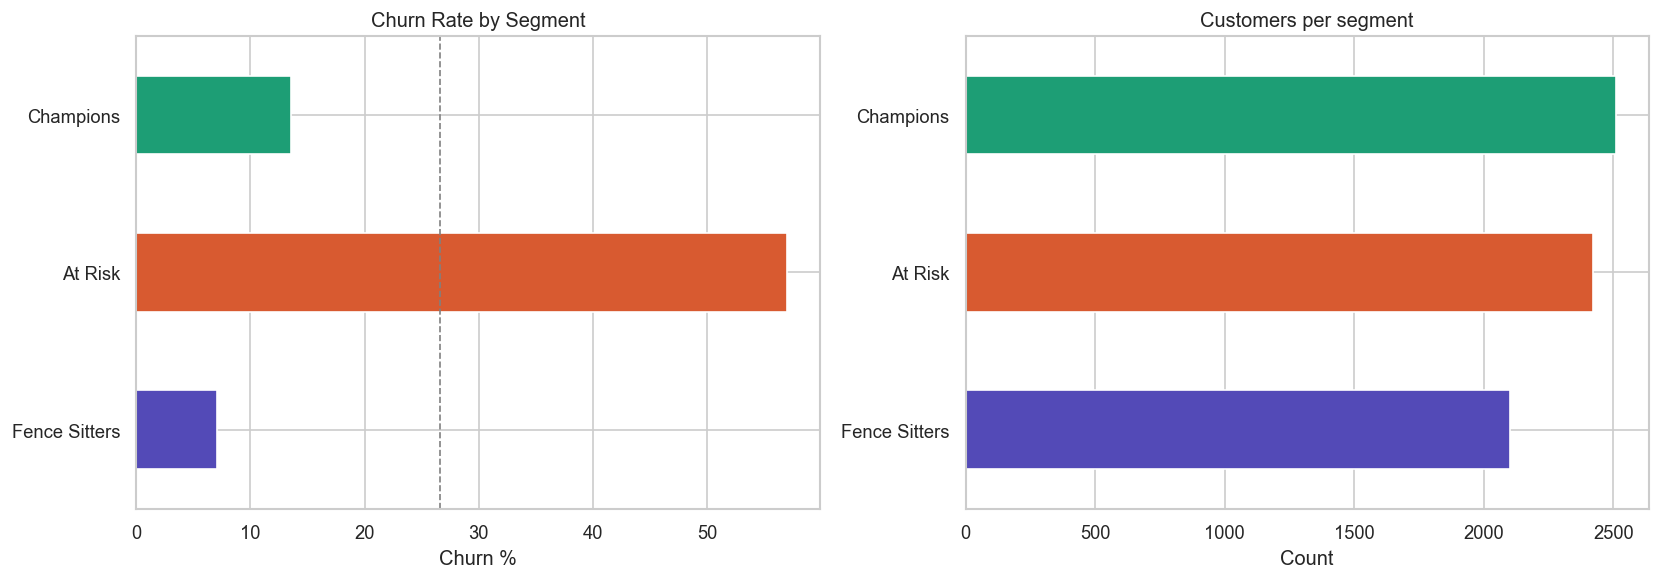

In [36]:
segment_order = ["Fence Sitters", "At Risk", "Champions"]
colors = ["#534AB7", "#D85A30", "#1D9E75"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

churn_by_seg = df.groupby("segment_names")["Churn"].mean() * 100
churn_by_seg = churn_by_seg.reindex(segment_order)
churn_by_seg.plot(
    kind="barh", ax=axes[0], color=colors
)
axes[0].set_title("Churn Rate by Segment")
axes[0].set_xlabel("Churn %")
axes[0].set_ylabel("")
avg_churn = df["Churn"].mean() * 100
axes[0].axvline(avg_churn, color="gray", linestyle="--", linewidth=1)

count_by_seg = df["segment_names"].value_counts()
count_by_seg = count_by_seg.reindex(segment_order)
count_by_seg.plot(
    kind="barh", ax=axes[1], color=colors
)
axes[1].set_title("Customers per segment")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## 7. PCA Visualisation
Reducing 4 clustering features to 2D to visualise segment separation.

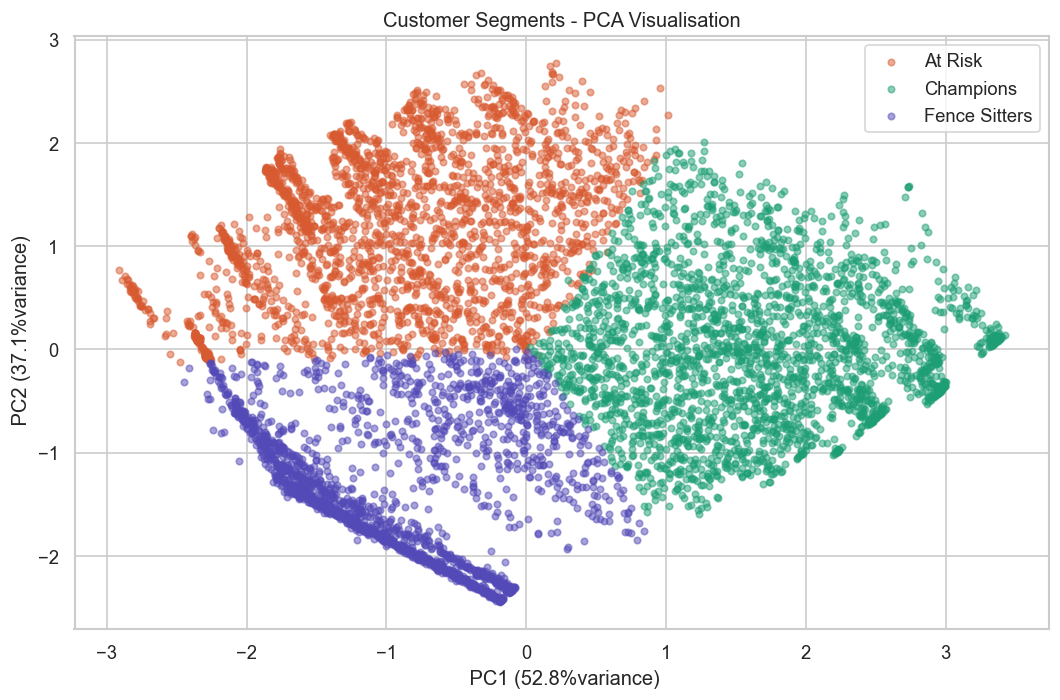

 Total variance explained: 89.9%


In [38]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1"          : X_pca[:,0],
    "PC2"          : X_pca[:,1],
    "segment_names": df["segment_names"]
})

color_map = {
    "Champions"     : "#1D9E75",
    "At Risk"       : "#D85A30",
    "Fence Sitters" : "#534AB7"
}

fig, ax = plt.subplots(figsize=(9, 6))
for name, group in pca_df.groupby("segment_names"):
    ax.scatter(group["PC1"], group["PC2"],
               label=name,
               color=color_map.get(name, "gray"),
               alpha=0.5, s=15)
    
ax.set_title("Customer Segments - PCA Visualisation")
ax.set_xlabel(f" PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%variance)")
ax.set_ylabel(f" PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%variance)")
ax.legend()
plt.tight_layout()
plt.show()

print(f" Total variance explained: {sum(pca.explained_variance_ratio_)*100:.1f}%")


## 8. Retention Strategy per Segment

In [ ]:
from tabulate import tabulate

strategy = pd.DataFrame({
    "Segment": ["Champions", "At Risk", "Fence Sitters"],

    "Priority": ["Low", "High", "Medium"],

    "Avg CLV": ["$4743", "$883", "$956"],

    "Action": [
        "Loyalty rewards — keep them happy",
        "Contract upgrade offer + personal call",
        "Bundle more services at discount"
    ],

    "Offer": [
        "Cashback or referral bonus",
        "20% off annual contract switch",
        "Free add-on service for 3 months"
    ]
})

print(
    tabulate(
        strategy,
        headers="keys",
        tablefmt="rounded_grid",
        showindex=False
    )
)

╭───────────────┬────────────┬───────────┬────────────────────────────────────────┬──────────────────────────────────╮
│ Segment       │ Priority   │ Avg CLV   │ Action                                 │ Offer                            │
├───────────────┼────────────┼───────────┼────────────────────────────────────────┼──────────────────────────────────┤
│ Champions     │ Low        │ $4743     │ Loyalty rewards — keep them happy      │ Cashback or referral bonus       │
├───────────────┼────────────┼───────────┼────────────────────────────────────────┼──────────────────────────────────┤
│ At Risk       │ High       │ $883      │ Contract upgrade offer + personal call │ 20% off annual contract switch   │
├───────────────┼────────────┼───────────┼────────────────────────────────────────┼──────────────────────────────────┤
│ Fence Sitters │ Medium     │ $956      │ Bundle more services at discount       │ Free add-on service for 3 months │
╰───────────────┴────────────┴───────────┴──────

## 9. Save Segmented Data

In [53]:
df.to_csv("..//data/processed/telco_churn_segmented.csv", index=False)
print("Saved! Shape:", df.shape)
print("New columns added: segment, segment_name, churn_probability")

Saved! Shape: (7032, 29)
New columns added: segment, segment_name, churn_probability


## Key Findings

| Segment | Customers | Churn Rate | Avg CLV | Priority | Action |
|---------|-----------|------------|---------|----------|--------|
| Champions | 2,511 | 14.0% | $4,743 | Low | Loyalty rewards + cashback |
| At Risk | 2,421 | 57.0% | $883 | High | 20% off annual contract switch |
| Fence Sitters | 2,100 | 7.0% | $956 | Medium | Free add-on service for 3 months |

<br>

> **Business Impact:** At Risk segment has 2,421 customers churning at 57% —  
> retaining even 30% of them saves approximately **$152,000 in CLV**  
> (2,421 × 57% × 30% × $883 ≈ $366,000 potential revenue protected)

**Next → `streamlit_app.py`** — Live Dashboard